In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

In [2]:
#------------------------------
# Geometrical Constants
#------------------------------

Rout = 12.0 #outer radius in mm
Rin =  1/3*Rout
L0 = 13 #max height in mm
h = 3 #step height in mm
cl  = 6.7*1e6 #longitudinal wave speed in mm/s
ct  = 5.4*1e6 #transverse wave speed in mm/s
eps = 1e-8
m   = 1

In [3]:
def L(r):
    return L0 - h * 0.5 * (1 + np.tanh((r - Rin)/eps))

In [18]:
Nr = 1000
rho = np.linspace(1e-4,2,Nr)#(np.arange(Nr) + 0.5)/Nr
drho = rho[1] - rho[0]

In [19]:
R0 = Rout

def ell(rho):
    r = R0*rho
    return L(r)/R0

In [20]:
rp = rho + drho/2
rm = rho - drho/2

main = (rp + rm)/(rho*drho**2)
upper = -rp/(rho*drho**2)
lower = -rm/(rho*drho**2)

# correggi i bordi per Neumann
main[0] = 2/drho**2
upper[0] = -2/drho**2
lower[0] = 0

main[-1] = 2/drho**2
lower[-1] = -2/drho**2
upper[-1] = 0

D = sp.diags(
    diagonals=[lower[1:], main, upper[:-1]],
    offsets=[-1, 0, 1],
    format="csr"
)

In [21]:
n = 1

Text(0.5, 1.0, 'Effect of centrifugal term, N=1')

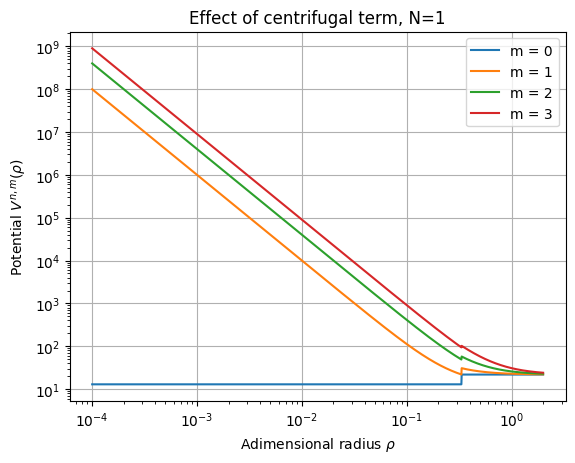

In [22]:
for emme in [0,1,2,3]:
    v = emme**2/rho**2 + (cl/ct)**2*(n*np.pi/ell(rho))**2
    plt.plot(rho, v, label=f'm = {emme}')
plt.loglog()
plt.xlabel(r'Adimensional radius $\rho$')
plt.ylabel(r'Potential $V^{n,m}(\rho)$')
plt.legend()
plt.grid()
plt.title('Effect of centrifugal term, N=1')

In [23]:
m = 0

In [35]:
results = {
    "N": [1,3,5],
    "eigvecs": [],
    "eigvals": [],
    "omegas":[],
    "V": []
}

In [36]:
for n in results["N"]:
    V = m**2/rho**2 + (cl/ct)**2*(n*np.pi/ell(rho))**2
    results["V"].append(V)
    A = D + sp.diags(V, 0)

    eigvals, eigvecs = spla.eigs(
        A,
        k=10,
        which="SM"
    )

    eigvals = np.real(eigvals)
    idx = np.argsort(eigvals)

    results["eigvals"].append(eigvals[idx])
    results["eigvecs"].append(eigvecs[:, idx])
    results["omegas"].append(np.sqrt(np.real(eigvals)))
    #print(f"{n}, {abs(eigvecs[:,0][-1]):.3}, {dpsi_drho[-1]:.3}")  # dovrebbe essere vicino a 0


In [37]:
def Confinement_ratio(psi, rho, rho_in):
    mask = rho < 1.0     
    rho_cut = rho[mask]
    psi_cut = psi[mask]
    density = np.abs(psi_cut)**2 * rho_cut
    I_tot = np.trapezoid(density, rho_cut)
    I_in  = np.trapezoid(density[rho_cut < rho_in],rho_cut[rho_cut < rho_in])
    return I_in / I_tot

def Loss(psi, rho):
    density = np.abs(psi)**2 * rho
    I_tot = np.trapezoid(density, rho)
    I_out  = np.trapezoid(density[rho > 1], rho[rho > 1])
    return I_out / I_tot

def HWHM(psi, rho):
    mask = rho < 1.0      
    rho_cut = rho[mask]
    psi_cut = psi[mask]
    psi = np.abs(np.asarray(psi))
    psi0 = psi[0]
    half = 0.5 * psi0

    idx = np.where(psi <= half)[0]

    if len(idx) == 0:
        raise ValueError("Half maximum non raggiunto nel dominio.")

    i = idx[0] - 1

    rho1, rho2 = rho[i], rho[i+1]
    psi1, psi2 = psi[i], psi[i+1]

    rho_half = rho1 + (half - psi1) * (rho2 - rho1) / (psi2 - psi1)

    return rho_half * Rout

In [39]:
results["CR"], results["Loss"], results["HWHM"] = [], [], []

rho_in = Rin / Rout

for i, n in enumerate(results["N"]):
    psi0 = results["eigvecs"][i][:, 0]   # ground radial mode
    #psi0 = normalize_cyl(np.real(psi0), rho)

    CR = Confinement_ratio(psi0, rho, rho_in)
    loss = Loss(psi0, rho)
    hwhm = HWHM(psi0, rho)
    results["CR"].append(CR)
    results["Loss"].append(loss)
    results["HWHM"].append(hwhm)

In [40]:
from scipy.optimize import curve_fit

In [41]:
def f(x, a, b, c, d):
    return a/(np.exp(-c*(x-b))+1) + d

In [42]:
try:
    popt, pcov = curve_fit(f, results["N"], results["CR"], maxfev=10000)

    plt.scatter(results["N"], results["CR"], marker='o', alpha=0.5, color='b')
    plt.plot(results["N"], f(results["N"], *popt), color='k',label='Logistic fit')
    plt.legend()
    plt.xlabel('N')
    plt.xticks(results["N"])
    plt.ylabel('Confinment Ratio')
    plt.grid()
except:
    pass

In [43]:
p1, _ = curve_fit(Exp, results["N"], results["Loss"], maxfev=10000)
p2, _ = curve_fit(Exp, results["N"], results["FWHM"], maxfev=10000)

NameError: name 'Exp' is not defined

NameError: name 'Exp' is not defined

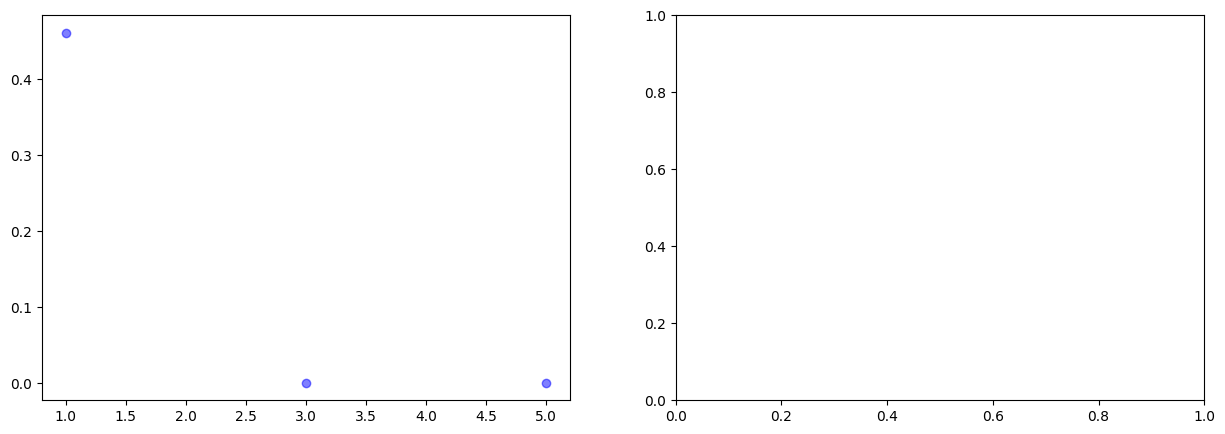

In [32]:
fig, axs = plt.subplots(1,2, figsize=(15,5))

axs[0].scatter(results["N"], results["Loss"], marker='o', alpha=0.5, color='b')
axs[0].plot(np.linspace(1, results["N"][-1],1000), Exp(np.linspace(1, results["N"][-1],1000), *p1), 
            color='navy', ls='-.', lw=2, 
            label=f"fit : {p1[0]:.2} exp(-{p1[1]:.2}) N + {p1[2]:.2}")
axs[0].set_xlabel('N', fontsize=14)
axs[0].set_xticks(results["N"])
axs[0].set_ylabel('Loss', fontsize=14)
axs[0].grid()

try:
    axs[1].scatter(results["N"], results["FWHM"], marker='o', alpha=0.5, color='b')
    axs[1].plot(np.linspace(1, results["N"][-1],1000), Exp(np.linspace(1, results["N"][-1],1000), *p2), 
                color='navy', ls='-.', lw=2, 
                label=f"fit : {p2[0]:.2} exp(-{p2[1]:.2}) N + {p2[2]:.2}")
    axs[1].set_xlabel('N', fontsize=14)
    axs[1].set_xticks(results["N"])
    axs[1].set_ylabel('HWHM [mm]', fontsize=14)
    axs[1].grid()
except:
    pass

axs[0].legend()
axs[1].legend()
fig.suptitle(f"L={L0} mm,\t h={h} mm,\t"+r"$\rho_{in}$"+f"={rho_in:.2}", fontsize=16)
plt.tight_layout()
#plt.savefig(f"CRandLoss_L={L0}_h={h}_Rin={Rin:.2}.png", dpi=300)

In [44]:
def normalize_cyl(psi, rho):
    norm = np.trapezoid(psi**2 * rho, rho)
    return psi / np.sqrt(norm)

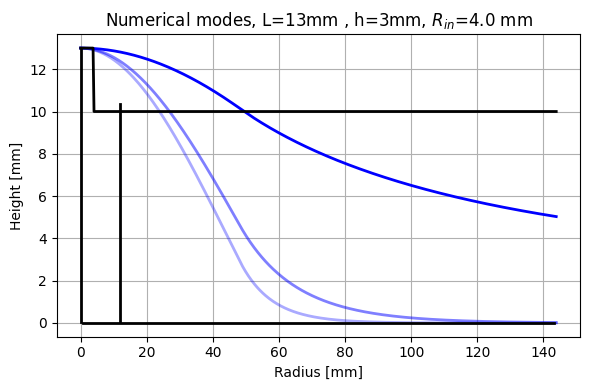

In [49]:
plt.figure(figsize=(6,4))
mask = rho < 1.0      
rho_c = rho[mask] * Rout

for i,n in enumerate([1,3,5]):

    psi_num = normalize_cyl(results["eigvecs"][i][:,0][mask], rho_c*Rout)
    psi_num *= L(0)/psi_num[0]
    plt.plot(rho_c*Rout, np.abs(psi_num), lw=2, color='b', alpha=1/(i+1), label=f'Numerical N={n}')

#plt.plot(rho*7, L0-1/5*(rho)**2, color='k', lw=2, ls='--', alpha=0.5, label='BAUSCIA')
#plt.axvline(7, 0.05, 0.75, color='k', alpha=0.5, lw=2, ls='--')
plt.plot(rho_c*R0, L(rho_c*R0), color='k', lw=2, label='MAGE')
plt.axvline(0, 0.05, 0.95, color='k', lw=2, ls='-')
plt.axhline(0, 0.05, 0.95, color='k', lw=2)
plt.axvline(Rout, 0.05, (L0-h)/L0, color='k', lw=2, ls='-')
plt.title('Radial Prodiles')
plt.tight_layout()
plt.xlabel('Radius [mm]')
plt.ylabel(r"Height [mm]")
#plt.legend(loc='upper right')
plt.grid()
plt.title(f"Numerical modes, L={L0}mm , h={h}mm, "+r"$R_{in}$"+f"={Rin:.3} mm")
plt.tight_layout()

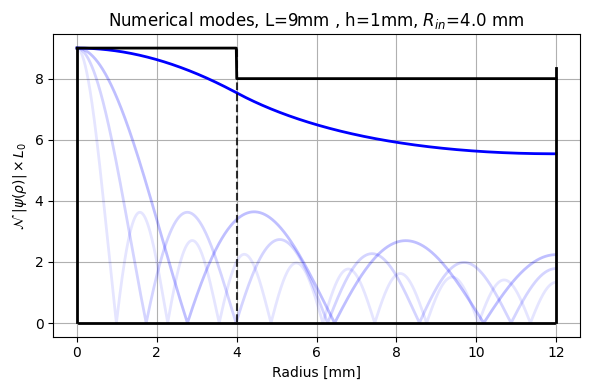

In [ ]:
plt.figure(figsize=(6,4))
for j in [0,3,5,9]:
    # numerical
    psi_num = normalize_cyl(results["eigvecs"][0][:,j], rho)
    psi_num *= L(rho*Rout)[0]/psi_num[0]
    plt.plot(rho*Rout, np.abs(psi_num), lw=2, color='b', alpha=1/(j+1), label=f'N={j+1}')

plt.plot(rho*Rout, L(rho*Rout), color='k', lw=2)
plt.axvline(0, 0.05, 0.95, color='k', lw=2, ls='-')
plt.axhline(0, 0.05, 0.95, color='k', lw=2)
plt.axvline(Rout, 0.05, (L(rho[-1]*Rout))/L0, color='k', lw=2, ls='-')
plt.title('Radial Prodile')
plt.xlabel('Adimensional radius')
plt.ylabel('Height [mm]')
plt.tight_layout()
plt.xlabel('Radius [mm]')
plt.axvline(Rin, 0.05, 0.95, linestyle='--', color='k', alpha=0.8, label=r'$R_{in}$')
plt.ylabel(r"$\mathcal{N}$ "+r"$|\psi(\rho)| \times L_0$")
plt.title(f"Numerical modes, L={L0}mm , h={h}mm, "+r"$R_{in}$"+f"={Rin:.3} mm")
#plt.legend()
plt.grid()
plt.tight_layout()
#plt.savefig(f"modes_L={L0}_h={h}_Rin={Rin:.2}.png", dpi=300)

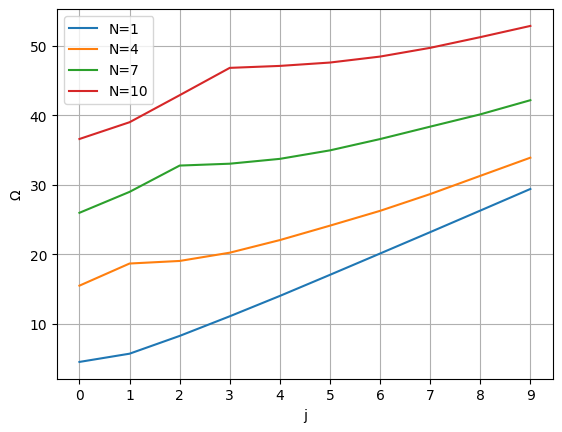

In [440]:
for i,w in enumerate(results["omegas"][::3]):
    plt.plot(w, label=f"N={i*3+1}")
plt.legend()
plt.xticks(range(10))
plt.xlabel('j')
plt.ylabel(r'$\Omega$')
plt.grid()

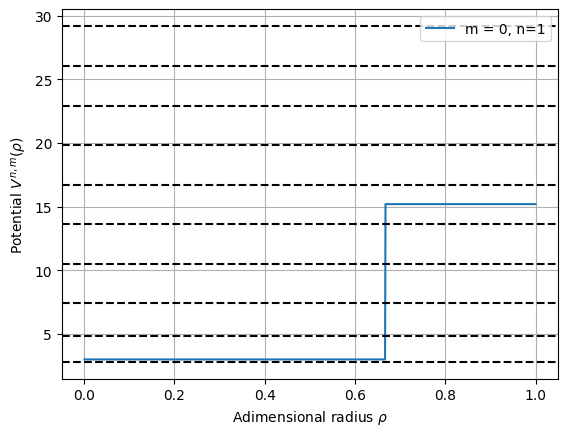

In [ ]:
plt.plot(rho, results["V"][0], label=f'm = {0}, n=1')
for w in results["omegas"][0]:
    plt.axhline(w, 0, 1, color='k', ls='--')
plt.xlabel(r'Adimensional radius $\rho$')
plt.ylabel(r'Potential $V^{n,m}(\rho)$')
plt.legend()
plt.grid()